# Demonstrating Signal Filtering (Low-Pass 40Hz)

**Goal:** Visualize the effect of the Low-Pass Filter on EEG signals.

We apply a **40 Hz Low-Pass Butterworth Filter** to remove high-frequency noise and muscle artifacts (EMG), retaining the biologically relevant Delta, Theta, Alpha, and Beta bands.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch

# Add src to path
sys.path.append(os.path.abspath('..'))
from src.data_processing.loader import load_bonn_data
from src.data_processing.filtering import apply_lowpass_filter

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load data
data_path = os.path.join(os.path.abspath('..'), 'data', 'raw')
X, y = load_bonn_data(data_path)

# Select a sample signal (Seizure class often has high freq components)
idx = np.where(y == 1)[0][0]
raw_signal = X[idx]

# Apply Filter
filtered_signal = apply_lowpass_filter(raw_signal, cutoff=40.0)

print(f"Signal shape: {raw_signal.shape}")

Loading 100 files from Z (Class 0)...
Loading 100 files from O (Class 0)...
Loading 100 files from N (Class 0)...
Loading 100 files from F (Class 0)...
Loading 100 files from S (Class 1)...
Signal shape: (4097,)


## Time-Domain Comparison

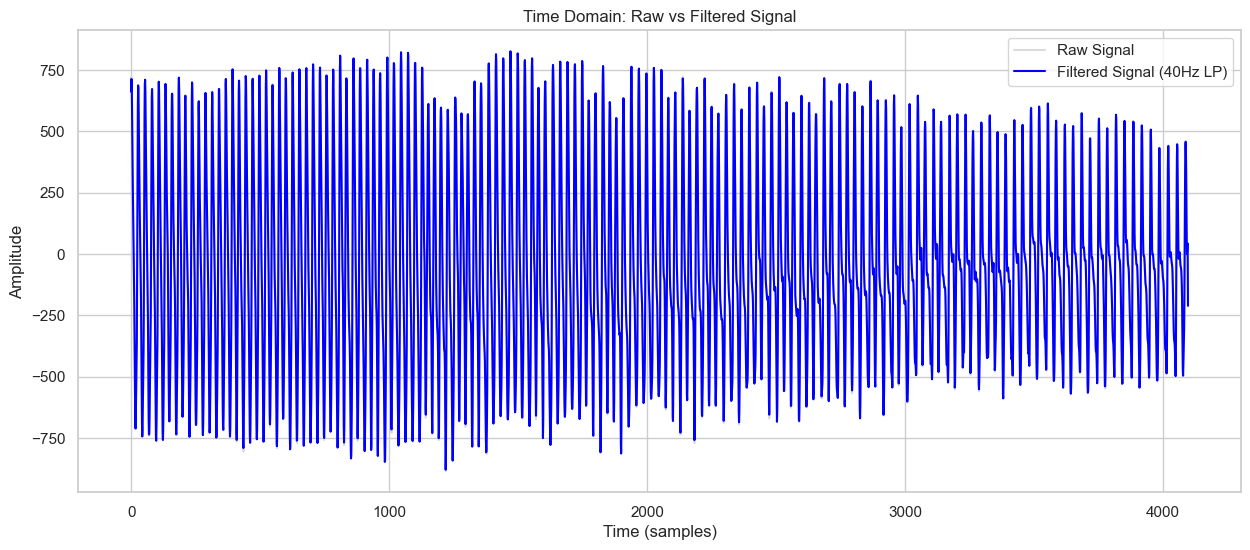

In [3]:
plt.figure(figsize=(15, 6))
plt.plot(raw_signal, label='Raw Signal', color='lightgray', alpha=0.8)
plt.plot(filtered_signal, label='Filtered Signal (40Hz LP)', color='blue', linewidth=1.5)
plt.title('Time Domain: Raw vs Filtered Signal')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

## Frequency-Domain Comparison (PSD)
We expect to see a sharp drop in power above 40 Hz.

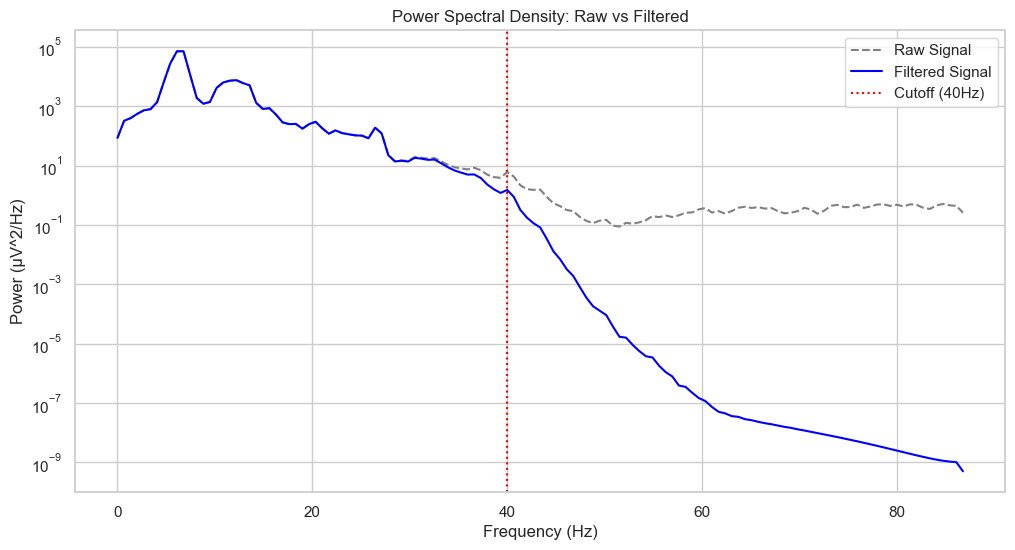

In [4]:
fs = 173.61
f_raw, Pxx_raw = welch(raw_signal, fs=fs, nperseg=256)
f_filt, Pxx_filt = welch(filtered_signal, fs=fs, nperseg=256)

plt.figure(figsize=(12, 6))
plt.semilogy(f_raw, Pxx_raw, label='Raw Signal', color='gray', linestyle='--')
plt.semilogy(f_filt, Pxx_filt, label='Filtered Signal', color='blue')
plt.axvline(x=40, color='red', linestyle=':', label='Cutoff (40Hz)')

plt.title('Power Spectral Density: Raw vs Filtered')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (µV^2/Hz)')
plt.legend()
plt.grid(True)
plt.show()